# Лекція 2 — демонстрація в Python

## Оптимізаційні задачі та аналіз чутливості

**Курс:** Інтелектуальний аналіз та візуалізація даних (СК26)

---

Ті самі дві моделі, які ми щойно розібрали в Excel:

| Модель | Файл Excel | Про що |
|---|---|---|
| **Simon Pie Co.** | `Retail.xlsx` | одна змінна рішення, оптимум без обмежень |
| **Oak Products** | `Стільці_3.xlsx` | багато змінних рішення та обмежені ресурси |

Мета демонстрації — **не** повторити Excel. Мета — показати три речі, яких Excel зробити не може:

1. записати модель так, щоб її можна було прочитати як текст і перевірити очима;
2. прогнати сотні сценаріїв одним циклом;
3. **побачити діапазон стійкості тіньової ціни** як злам на графіку, а не як число у звіті.

In [2]:
conda install pulp

Retrieving notices: ...working... done
done
Solving environment: failed with initial frozen solve. Retrying with flexible solve.
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.1.0
  latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c conda-forge conda

Or to minimize the number of packages updated during conda update use

     conda install conda=26.7.2


WARNING conda.models.version:get_matcher(546): Using .* with relational operator is superfluous and deprecated and will be removed in a future version of conda. Your spec was 1.9.0.*, but conda is ignoring the .* and treating it as 1.9.0
WARNING conda.models.version:get_matcher(546): Using .* with relational operator is superfluous and deprecated and will be removed in a future version of conda. Your spec was 1.8.0.*, but conda is ignoring the .* and treating it as 1.8.0
done
Solving environment: done


==> WARNING: A newer version of conda exists. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

NAVY, BLUE, AMBER, MUTED = '#12395B', '#3E7CA6', '#E2894A', '#5A6B7A'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlelocation': 'left', 'axes.titleweight': 'bold', 'axes.titlesize': 12,
    'axes.labelcolor': MUTED, 'axes.edgecolor': '#DDE4EA', 'axes.labelsize': 10,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'font.size': 10,
    'grid.color': '#E6EBEF', 'lines.linewidth': 2.2,
})
pd.set_option('display.width', 160)
print('pulp', pulp.__version__)

pulp 2.8.0


---
# Частина 1. Simon Pie — модель як функція

В Excel модель була таблицею. У Python вона стає функцією — і в цьому вся різниця:
функцію можна викликати тисячу разів.

Зверніть увагу на структуру: спершу **параметри**, потім **змінна рішення** як аргумент,
потім **наслідки**. Той самий поділ на три групи, що й на аркуші Excel.

In [4]:
# --- параметри (те, що нам дано) --------------------------------------------
c_обробка   = 2.05      # витрати на обробку одного пирога
c_начинка   = 3.48
c_тісто     = 0.30
постійні    = 12.00     # тис. $ на тиждень
a, b        = 48.0, -4.0   # рівняння попиту:  D = a + b*P

змінні_витрати = c_обробка + c_начинка + c_тісто
print('змінні витрати на пиріг: $%.2f' % змінні_витрати)

# --- модель: єдина змінна рішення — ціна ------------------------------------
def simon_pie(ціна):
    попит   = a + b * ціна           # НАСЛІДОК, а не змінна рішення
    дохід   = попит * ціна
    витрати = змінні_витрати * попит + постійні
    return {'ціна': ціна, 'попит': попит, 'дохід': дохід,
            'витрати': витрати, 'прибуток': дохід - витрати}

pd.DataFrame([simon_pie(p) for p in [6, 7, 8, 9, 9.5, 10, 11]]).round(2)

змінні витрати на пиріг: $5.83


,ціна,попит,дохід,витрати,прибуток
0,6.0,24.0,144.0,151.92,-7.92
1,7.0,20.0,140.0,128.60,11.40
2,8.0,16.0,128.0,105.28,22.72
3,9.0,12.0,108.0,81.96,26.04
4,9.5,10.0,95.0,70.30,24.70
5,10.0,8.0,80.0,58.64,21.36
6,11.0,4.0,44.0,35.32,8.68


### Той самий перебір, що на аркуші «Альтернативи» — але в один рядок

В Excel сім варіантів були сімома копіями моделі. Тут — сім викликів функції.
Різниця стає відчутною, коли варіантів не сім, а сімсот.

In [5]:
ціни = np.arange(5.9, 12.01, 0.02)
прибутки = np.array([simon_pie(p)['прибуток'] for p in ціни])

i = прибутки.argmax()
p_opt, pr_opt = ціни[i], прибутки[i]

# аналітичний оптимум: похідна квадратичної функції
p_teor = -(a - змінні_витрати * b) / (2 * b)
print('перебором:      ціна %.3f   прибуток %.3f' % (p_opt, pr_opt))
print('аналітично:     ціна %.3f   прибуток %.3f' % (p_teor, simon_pie(p_teor)['прибуток']))
print('попит в оптимумі: %.2f тис. пирогів' % simon_pie(p_teor)['попит'])

перебором:      ціна 8.920   прибуток 26.069
аналітично:     ціна 8.915   прибуток 26.069
попит в оптимумі: 12.34 тис. пирогів


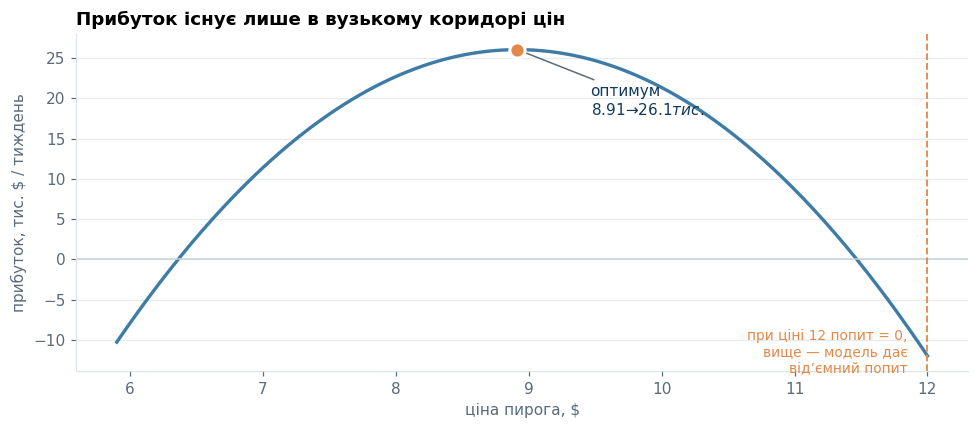

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ціни, прибутки, color=BLUE)
ax.axhline(0, color='#C8D2DA', linewidth=1)
ax.plot([p_teor], [simon_pie(p_teor)['прибуток']], 'o', color=AMBER, markersize=10,
        markeredgecolor='white', markeredgewidth=2, zorder=5)
ax.annotate('оптимум\n$%.2f → %.1f тис. $' % (p_teor, simon_pie(p_teor)['прибуток']),
            xy=(p_teor, simon_pie(p_teor)['прибуток']), xytext=(p_teor + 0.55, 18),
            fontsize=10, color=NAVY,
            arrowprops=dict(arrowstyle='-', color=MUTED, linewidth=1))
ax.axvline(12, color=AMBER, linestyle='--', linewidth=1.2)
ax.text(11.85, -14, 'при ціні 12 попит = 0,\nвище — модель дає\nвід’ємний попит',
        ha='right', fontsize=9, color=AMBER)
ax.set_title('Прибуток існує лише в вузькому коридорі цін')
ax.set_xlabel('ціна пирога, $'); ax.set_ylabel('прибуток, тис. $ / тиждень')
ax.grid(axis='y')
fig.tight_layout(); plt.show()

**Два висновки з одного графіка.**

Оптимум є тому, що в моделі є зворотний зв'язок: вища ціна дає більшу маржу з пирога,
але менший попит. Прибрати рівняння попиту — і крива перетвориться на пряму, що росте
без кінця, тобто в модель з аркуша `Модель1`.

І друге, важливіше: **модель чинна не всюди**. Рівняння `D = 48 − 4·P` оцінене з
реальних спостережень у якомусь діапазоні цін. При ціні 12 воно дає нульовий попит,
а вище — від'ємний. Формула цього не знає і продовжить рахувати. Знати мусите ви.

---
# Частина 2. Oak Products — задача з обмеженнями

Тепер змінних рішення кілька, і вони конкурують за спільні ресурси.
Спрощена модель з лекції: два типи стільців.

Порівняйте цей запис із формулюванням на слайді — це майже дослівний переклад.

In [7]:
модель = pulp.LpProblem('Oak_Products_2', pulp.LpMaximize)

# ЗМІННІ РІШЕННЯ
C = pulp.LpVariable('Captain', lowBound=0)
M = pulp.LpVariable('Mate',    lowBound=0)

# ЩО РОБИМО НАЙБІЛЬШИМ
модель += 56 * C + 40 * M, 'прибуток'

# ОБМЕЖЕННЯ (права частина — запас на складі)
модель += (8 * C +  4 * M <= 1280, 'довгі_штифти')
модель += (4 * C + 12 * M <= 1600, 'короткі_штифти')
модель += (4 * C +  4 * M <=  760, 'ніжки')
модель += (1 * C           <=  140, 'міцні_сидіння')
модель += (           1 * M <=  120, 'полегшені_сидіння')
модель += (    C +      M >=  100, 'мінімальний_план')

модель.solve(pulp.PULP_CBC_CMD(msg=0))

print('статус:', pulp.LpStatus[модель.status])
print('Captain: %.0f' % C.value())
print('Mate:    %.0f' % M.value())
print('прибуток: $%.0f' % pulp.value(модель.objective))

статус: Optimal
Captain: 130
Mate:    60
прибуток: $9680


Ті самі числа, що дав Solver: **130, 60, 9 680**. Різниця в тому, що тут видно, які саме
кнопки натиснули — модель записана текстом і збережеться у файлі разом із результатом.

### Тіньові ціни без окремого звіту

В Excel для цього треба замовити «Звіт про стійкість» окремим діалогом.
Тут вони вже лежать у розв'язку — це поле `.pi` кожного обмеження.

In [8]:
рядки = []
for назва, обм in модель.constraints.items():
    запас = -обм.constant                 # права частина нерівності
    використано = обм.value() - обм.constant
    рядки.append({
        'обмеження': назва.replace('_', ' '),
        'використано': round(використано, 1),
        'запас': round(запас, 1),
        'залишок': round(запас - використано, 1),
        'тіньова ціна': round(обм.pi, 2),
    })
звіт = pd.DataFrame(рядки)
звіт['стан'] = np.where(звіт['тіньова ціна'].abs() > 1e-9, 'вичерпано', 'у надлишку')
звіт

,обмеження,використано,запас,залишок,тіньова ціна,стан
0,довгі штифти,1280.0,1280,0.0,4.0,вичерпано
1,короткі штифти,1240.0,1600,360.0,-0.0,у надлишку
2,ніжки,760.0,760,0.0,6.0,вичерпано
3,міцні сидіння,130.0,140,10.0,-0.0,у надлишку
4,полегшені сидіння,60.0,120,60.0,-0.0,у надлишку
5,мінімальний план,190.0,100,-90.0,-0.0,у надлишку


**Як це читати.** Дефіцитні лише два ресурси: довгі штифти й ніжки.
Одна додаткова ніжка додає до прибутку $6, один додатковий довгий штифт — $4.
Решта ресурсів у надлишку, і їхня тіньова ціна нуль: докупити те, чого й так вистачає,
означає викинути гроші.

Це і є відповідь на питання зі слайда: якщо є бюджет на закупівлю, купувати треба
ніжки, а не короткі штифти.

---
# Частина 3. Повна модель — шість типів стільців

Ту саму задачу зручніше записати даними, а не переліком рядків. Тоді модель на шість
типів і одинадцять ресурсів займає стільки ж коду, скільки на два.

In [9]:
стільці = ['Capt', 'Mate', 'AmerHi', 'AmerLo', 'SpainK', 'SpainQ']
прибуток_шт = dict(zip(стільці, [36, 40, 45, 38, 35, 25]))

# ресурс: (скільки одиниць треба на кожен тип стільця, запас на складі)
ресурси = {
    'Довгі штифти':          ([8,  0, 12,  0, 8, 4], 1280),
    'Короткі штифти':        ([4, 12,  0, 12, 4, 8], 1900),
    'Ніжки':                 ([4,  4,  4,  4, 4, 4], 1090),
    'Міцні сидіння':         ([1,  0,  0,  0, 1, 1],  190),
    'Полегшені сидіння':     ([0,  1,  1,  1, 0, 0],  170),
    'Міцні поперечини':      ([6,  0,  4,  0, 5, 0], 1000),
    'Полегшені поперечини':  ([0,  4,  0,  5, 0, 6], 1000),
    'Спинки Capt':           ([1,  0,  0,  0, 0, 0],  110),
    'Спинки Mate':           ([0,  1,  0,  0, 0, 0],   72),
    'Спинки Amer':           ([0,  0,  1,  1, 0, 0],   93),
    'Спинки Span':           ([0,  0,  0,  0, 1, 1],   85),
}

def oak(запаси=None):
    """Розв'язує модель. `запаси` — словник із заміною запасу окремих ресурсів."""
    запаси = запаси or {}
    m = pulp.LpProblem('Oak', pulp.LpMaximize)
    x = {c: pulp.LpVariable(c, lowBound=0) for c in стільці}
    m += pulp.lpSum(прибуток_шт[c] * x[c] for c in стільці)
    ключ = {}
    for i, (назва, (коеф, запас)) in enumerate(ресурси.items()):
        ключ[назва] = 'r%d' % i          # PuLP не любить пробілів у назвах
        m += (pulp.lpSum(k * x[c] for k, c in zip(коеф, стільці))
              <= запаси.get(назва, запас), ключ[назва])
    m.solve(pulp.PULP_CBC_CMD(msg=0))
    return {
        'прибуток': pulp.value(m.objective),
        'план': {c: x[c].value() for c in стільці},
        'тіньові': {n: m.constraints[ключ[n]].pi for n in ресурси},
        'зведені': {c: x[c].dj for c in стільці},
    }

r = oak()
print('прибуток: $%.0f\n' % r['прибуток'])
pd.DataFrame({'прибуток за штуку': прибуток_шт, 'оптимальний план': r['план']})

прибуток: $10294



,прибуток за штуку,оптимальний план
Capt,36,100.0
Mate,40,72.0
AmerHi,45,40.0
AmerLo,38,53.0
SpainK,35,0.0
SpainQ,25,0.0


### Чому обидва іспанські стільці — нуль?

Питання зі слайда. Відповідь дає **зведена оцінка** (reduced cost) — на скільки мусив би
зрости прибуток за штуку, щоб цей тип узагалі увійшов у план.

In [10]:
зв = pd.DataFrame({
    'прибуток за штуку': прибуток_шт,
    'план': r['план'],
    'зведена оцінка': {c: round(v, 2) for c, v in r['зведені'].items()},
})
зв['потрібен прибуток'] = зв['прибуток за штуку'] - зв['зведена оцінка']
зв.round(2)

,прибуток за штуку,план,зведена оцінка,потрібен прибуток
Capt,36,100.0,0.00,36.00
Mate,40,72.0,0.00,40.00
AmerHi,45,40.0,-0.00,45.00
AmerLo,38,53.0,0.00,38.00
SpainK,35,0.0,-1.00,36.00
SpainQ,25,0.0,-8.67,33.67


**Ось точна відповідь.** SpainK давав би прибуток, якби приносив $36 замість $35 —
йому не вистачає рівно однієї гривні. SpainQ відстає значно більше: щоб увійти в план,
він мусив би приносити $33,67 замість $25.

І це не тому, що вони «мало прибуткові». SpainK приносить $35 і споживає 8 довгих
штифтів — стільки ж, скільки AmerHi, який приносить $45. Кожен виготовлений
іспанський стілець забирає дефіцитні штифти в американського.

**Рішення визначає не прибутковість штуки, а споживання дефіцитного ресурсу.**

In [11]:
т = pd.DataFrame({'тіньова ціна': {n: round(v, 2) for n, v in r['тіньові'].items()}})
т['стан'] = np.where(т['тіньова ціна'].abs() > 1e-9, 'дефіцит', 'у надлишку')
т.sort_values('тіньова ціна', ascending=False)

,тіньова ціна,стан
Спинки Mate,8.67,дефіцит
Спинки Amer,6.67,дефіцит
Довгі штифти,3.19,дефіцит
Короткі штифти,2.61,дефіцит
Міцні поперечини,-0.00,у надлишку
Міцні сидіння,-0.00,у надлишку
Ніжки,-0.00,у надлишку
Полегшені поперечини,-0.00,у надлишку
Полегшені сидіння,-0.00,у надлишку
Спинки Capt,-0.00,у надлишку


Найдорожчий ресурс — **спинки для Mate: $8,67 за одиницю**. Саме їх треба
докуповувати першими. І саме на цьому числі побудована наступна частина.

---
# Частина 4. Те, чого Excel не може

Тіньова ціна $8,67 чинна **не завжди**. Вона працює доти, доки структура розв'язку не
змінилася — тобто доки в дефіцит не впіймався якийсь інший ресурс. Excel повідомляє цю
межу числом у звіті про стійкість. Ми зараз побачимо її очима.

Прогоняємо модель для кожного значення запасу спинок Mate від 55 до 145 — це **91
розв'язання задачі**. В Excel це 91 запуск Solver вручну.

In [10]:
запаси = np.arange(55, 146)
крива = np.array([oak({'Спинки Mate': int(s)})['прибуток'] for s in запаси])
print('розв’язано задач:', len(крива))
print('прибуток при базовому запасі 72: $%.2f' % крива[запаси.tolist().index(72)])

розв’язано задач: 91
прибуток при базовому запасі 72: $10294.00


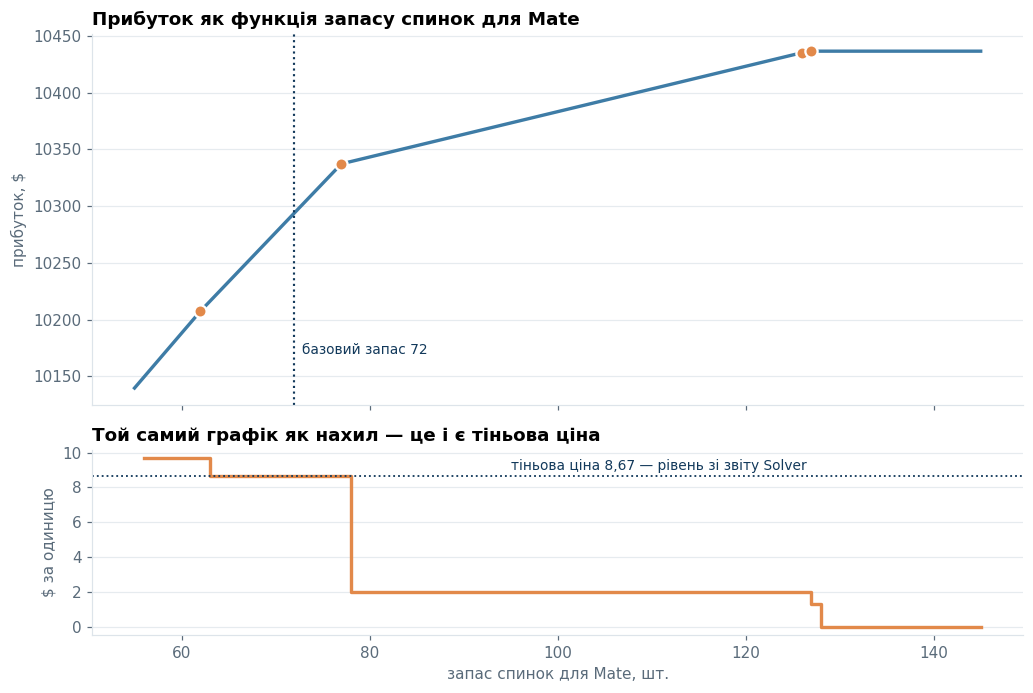

точки зламу: [62, 77, 126, 127]
нахили між зламами: [9.67, 8.67, 2.0, 1.33, 0.0]


In [11]:
нахили = np.round(np.diff(крива), 2)         # приріст прибутку на одну спинку
злами = [i for i in range(1, len(нахили)) if abs(нахили[i] - нахили[i-1]) > 0.05]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(запаси, крива, color=BLUE)
ax1.axvline(72, color=NAVY, linestyle=':', linewidth=1.4)
ax1.text(72.8, крива.min() + 30, 'базовий запас 72', fontsize=9, color=NAVY)
for i in злами:
    ax1.plot([запаси[i]], [крива[i]], 'o', color=AMBER, markersize=8,
             markeredgecolor='white', markeredgewidth=1.5, zorder=5)
ax1.set_title('Прибуток як функція запасу спинок для Mate')
ax1.set_ylabel('прибуток, $'); ax1.grid(axis='y')

ax2.step(запаси[1:], нахили, where='post', color=AMBER)
ax2.axhline(8.667, color=NAVY, linestyle=':', linewidth=1.2)
ax2.text(95, 9.0, 'тіньова ціна 8,67 — рівень зі звіту Solver', fontsize=9, color=NAVY)
ax2.set_title('Той самий графік як нахил — це і є тіньова ціна')
ax2.set_xlabel('запас спинок для Mate, шт.'); ax2.set_ylabel('$ за одиницю')
ax2.grid(axis='y')

fig.tight_layout(); plt.show()

print('точки зламу:', [int(запаси[i]) for i in злами])
print('нахили між зламами:', sorted(set(нахили.tolist()), reverse=True))

**Що ми щойно побачили.**

Нижній графік — це тіньова ціна, намальована як функція. Вона **кускова**:

| Запас спинок Mate | Нахил | Що це означає |
|---|---|---|
| нижче 62 | **9,67** | тут спинки в ще гіршому дефіциті — кожна втрачена коштує дорожче |
| 62 … 77 | **8,67** | робочий інтервал: це і є тіньова ціна зі звіту Solver |
| 78 … 126 | **2,00** | спинки перестали бути головним обмеженням, у дефіцит впіймався інший ресурс |
| понад 127 | **0** | докуповувати більше немає сенсу: прибуток уже не росте |

Інтервал, на якому нахил дорівнює 8,67, і є **діапазон стійкості** тіньової ціни.
У звіті Solver він записаний двома числами. Тут його видно.

Зверніть увагу на асиметрію: праворуч від базової точки 72 тіньова ціна тримається
лише до 77, а ліворуч від 62 стає навіть вищою. **Втратити дефіцитний ресурс болючіше,
ніж корисно його докупити** — тому запас треба насамперед захищати, а не наростити.

Практичний висновок для директора фабрики: спинки для Mate варто докупити, але
приблизно **п'ять штук** — далі за них уже не варто платити 8,67.

---
# Частина 5. Уся чутливість одним циклом

І остання перевага. Попередній графік ми побудували для одного ресурсу.
Тепер зробимо те саме **для всіх одинадцяти** — і подивимося, докуповування чого
справді змінює прибуток.

In [12]:
кроки = [-10, -5, 0, 5, 10]
таблиця = {}
for назва, (_, запас) in ресурси.items():
    таблиця[назва] = {('%+d' % d if d else 'базовий'):
                      round(oak({назва: запас + d})['прибуток'], 1) for d in кроки}

чутливість = pd.DataFrame(таблиця).T
чутливість['виграш від +10'] = (чутливість['+10'] - чутливість['базовий']).round(1)
чутливість.sort_values('виграш від +10', ascending=False)

,-10,-5,базовий,+5,+10,виграш від +10
Спинки Mate,10207.3,10250.7,10294.0,10337.3,10347.3,53.3
Спинки Amer,10227.3,10260.7,10294.0,10327.3,10327.3,33.3
Довгі штифти,10262.1,10278.0,10294.0,10310.0,10325.9,31.9
Короткі штифти,10267.9,10280.9,10294.0,10307.1,10320.1,26.1
Ніжки,10294.0,10294.0,10294.0,10294.0,10294.0,0.0
Міцні сидіння,10294.0,10294.0,10294.0,10294.0,10294.0,0.0
Полегшені сидіння,10260.7,10294.0,10294.0,10294.0,10294.0,0.0
Полегшені поперечини,10294.0,10294.0,10294.0,10294.0,10294.0,0.0
Міцні поперечини,10294.0,10294.0,10294.0,10294.0,10294.0,0.0
Спинки Capt,10294.0,10294.0,10294.0,10294.0,10294.0,0.0


Один цикл, п'ятдесят п'ять розв'язань задачі, повна картина.

Видно, що докупівля має сенс лише для чотирьох ресурсів з одинадцяти, і що
найбільший виграш дають спинки для Mate. Видно також, що зменшення запасу
дефіцитного ресурсу шкодить сильніше, ніж збільшення допомагає — бо праворуч від
базової точки тіньова ціна падає, а ліворуч тримається.

Зробити цю таблицю в Excel означало б п'ятдесят п'ять разів відкрити Solver
і п'ятдесят п'ять разів переписати число в клітинці.

---
# Підсумок

| | Excel | Python |
|---|---|---|
| **Сильна сторона** | видно кожну формулу, модель можна показати керівникові | модель читається як текст, дії зафіксовані у файлі |
| **Межа** | 200 змінних, ручні запуски, результат не відтворюється | формул не видно, поки не запустиш |
| **Коли брати** | зрозуміти задачу, показати, погодити | масштабувати, повторити, прогнати сотні сценаріїв |

**Excel — щоб зрозуміти й показати. Python — щоб масштабувати й повторити.**

Обидва інструменти розв'язують ту саму задачу і дають ті самі числа. Обирають не за
модою, а за тим, скільки разів цю задачу доведеться розв'язати.

---

### Що з цього буде на лабораторній роботі № 2

1. Побудувати оптимізаційну модель в Excel і розв'язати надбудовою Solver.
2. Замовити звіт про стійкість і прочитати з нього тіньові ціни та діапазони.
3. Повторити ту саму задачу в Python і **порівняти звіт Excel зі своїм графіком чутливості**.
4. Відповісти на питання: який ресурс докупити першим, скільки саме і чому не більше.